# Candlesticks as bars

Sample code preserving the legacy `plot_csbars` renderer removed from `Candlesticks` (the old `use_bars=True` path): candlesticks drawn as two `ax.bar` calls — zero-width bars for the wicks, filled bars for the bodies.

Kept for reference only: per-bar Rectangle artists are much slower than the `PolyCollection` renderer that replaced them (`plot_cspoly`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mplchart.samples import sample_prices

prices = sample_prices().tail(120)
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


In [2]:
def plot_csbars(prices, *, ax=None, width=0.8, alpha=1.0,
                colorup="black", colordn="black", coloroff="white"):
    """Candlesticks as two ax.bar calls (legacy renderer, verbatim logic)."""
    ax = ax or plt.gca()

    open_ = np.asarray(prices["open"], dtype=float)
    high = np.asarray(prices["high"], dtype=float)
    low = np.asarray(prices["low"], dtype=float)
    close = np.asarray(prices["close"], dtype=float)
    xvalues = np.arange(len(prices))  # rownum x — no date machinery here

    up = close >= open_
    upper = np.maximum(open_, close)
    lower = np.minimum(open_, close)

    edgecolor = np.where(up, colorup, colordn)
    facecolor = np.where(up, coloroff, colordn)

    # wicks: zero-width bars spanning low -> high
    ax.bar(xvalues, height=high - low, bottom=low,
           edgecolor=edgecolor, width=0.0, alpha=alpha, linewidth=0.7)
    # bodies: filled bars spanning open/close
    ax.bar(xvalues, height=upper - lower, bottom=lower,
           color=facecolor, edgecolor=edgecolor, width=width,
           alpha=alpha, fill=True, linewidth=0.7)

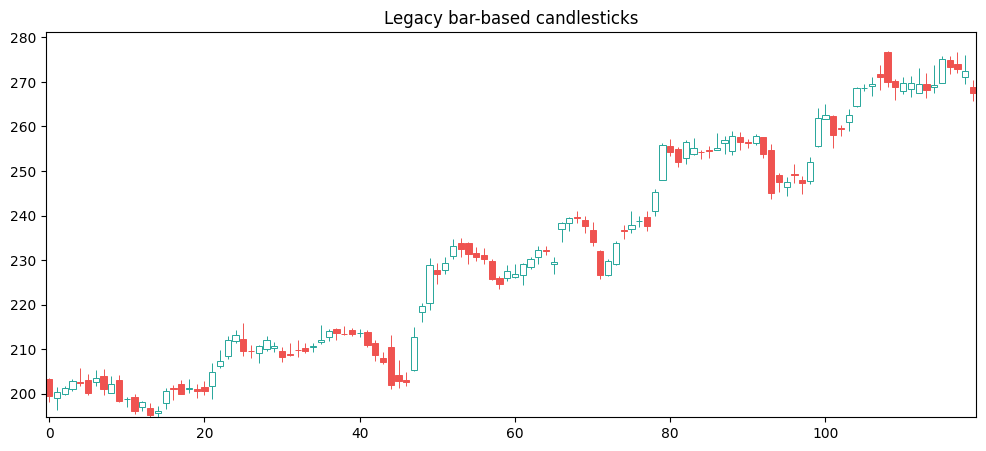

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_csbars(prices, ax=ax, colorup="#26a69a", colordn="#ef5350", coloroff="white")
ax.set_title("Legacy bar-based candlesticks")
ax.set_xmargin(0)
plt.show()